# LeetCode #239: Sliding Window Maximum

https://leetcode.com/problems/sliding-window-maximum/

## Comparison of Approaches
| Approach | Time | Space |
|---|---|---|
| Monotonic Deque ★ | O(n) | O(k) |
| Max Heap | O(n log n) | O(n) |
| Brute Force | O(n×k) | O(1) |

## Understanding the Methods
### Monotonic Deque (Optimal)
Maintain a deque storing indices in decreasing order of their values. For each new element, remove all smaller elements from the back (they can never be the max). Remove the front if it is outside the window. The front always holds the index of the current maximum.

### Max Heap
Push each element with its index. The top of the heap is the max, but we lazily remove elements that fall outside the window.

### Brute Force
For each window position, scan all k elements to find the max.

## Solutions

### C#

In [ ]:
public class Solution {
    public int[] MaxSlidingWindow(int[] nums, int k) {
        int n = nums.Length;
        int[] result = new int[n - k + 1];
        var deque = new LinkedList<int>();
        for (int i = 0; i < n; i++) {
            while (deque.Count > 0 && deque.First.Value < i - k + 1)
                deque.RemoveFirst();
            while (deque.Count > 0 && nums[deque.Last.Value] <= nums[i])
                deque.RemoveLast();
            deque.AddLast(i);
            if (i >= k - 1)
                result[i - k + 1] = nums[deque.First.Value];
        }
        return result;
    }
}

### Python

In [ ]:
from collections import deque

class Solution:
    def maxSlidingWindow(self, nums: list[int], k: int) -> list[int]:
        dq = deque()
        result = []
        for i, v in enumerate(nums):
            while dq and dq[0] < i - k + 1:
                dq.popleft()
            while dq and nums[dq[-1]] <= v:
                dq.pop()
            dq.append(i)
            if i >= k - 1:
                result.append(nums[dq[0]])
        return result

### Go

In [ ]:
func maxSlidingWindow(nums []int, k int) []int {
    n := len(nums)
    result := make([]int, 0, n-k+1)
    deque := []int{}
    for i := 0; i < n; i++ {
        for len(deque) > 0 && deque[0] < i-k+1 {
            deque = deque[1:]
        }
        for len(deque) > 0 && nums[deque[len(deque)-1]] <= nums[i] {
            deque = deque[:len(deque)-1]
        }
        deque = append(deque, i)
        if i >= k-1 {
            result = append(result, nums[deque[0]])
        }
    }
    return result
}

### Rust

In [ ]:
use std::collections::VecDeque;

impl Solution {
    pub fn max_sliding_window(nums: Vec<i32>, k: i32) -> Vec<i32> {
        let k = k as usize;
        let mut deque: VecDeque<usize> = VecDeque::new();
        let mut result = Vec::with_capacity(nums.len() - k + 1);
        for i in 0..nums.len() {
            while !deque.is_empty() && *deque.front().unwrap() + k <= i {
                deque.pop_front();
            }
            while !deque.is_empty() && nums[*deque.back().unwrap()] <= nums[i] {
                deque.pop_back();
            }
            deque.push_back(i);
            if i >= k - 1 {
                result.push(nums[*deque.front().unwrap()]);
            }
        }
        result
    }
}

## Example Scenarios

### 1. Common Case — Mixed Values
**Input:** `nums = [1, 3, -1, -3, 5, 3, 6, 7]`, `k = 3`

Windows and their maxima: `[1,3,-1]`$\to 3$, `[3,-1,-3]`$\to 3$, `[-1,-3,5]`$\to 5$, `[-3,5,3]`$\to 5$, `[5,3,6]`$\to 6$, `[3,6,7]`$\to 7$. The deque maintains a decreasing sequence of useful indices.

### 2. Slightly Complex — Descending Array
**Input:** `nums = [9, 8, 7, 6, 5, 4, 3]`, `k = 3`

Every window's maximum is its leftmost element. The deque always holds just the front element since each new element is smaller. Output: `[9, 8, 7, 6, 5]`. The deque never pops from the back — pure front expirations.

### 3. Edge Case: Time Factor — Ascending Array
**Input:** `nums = [1, 2, 3, ..., 100000]`, `k = 1`

With $k = 1$, each window is a single element. The deque is cleared and refilled at every step — each new element evicts all previous ones. Despite $10^5$ elements, amortized time is $O(n)$ since each index enters and leaves the deque exactly once.

### 4. Edge Case: Space Factor — Window Equals Array Length
**Input:** `nums = [5, 1, 4, 2, 3]`, `k = 5`

Only one window covering the entire array. The deque may hold up to $k = n$ indices — maximum space usage $O(k)$. Output is a single element: `[5]`. The deque stores `[0]` after processing (index of max value 5).

### 5. Almost-Impossible but Plausible — All Identical at INT Boundary
**Input:** `nums = [10000, 10000, ..., 10000]` ($10^5$ elements), `k = 50000`

All values equal the constraint maximum. The deque fills with all $k$ indices since no element evicts another. Every window maximum is $10{,}000$. Output has $n - k + 1 = 50{,}001$ identical entries. Tests that the deque handles no-eviction scenarios correctly.

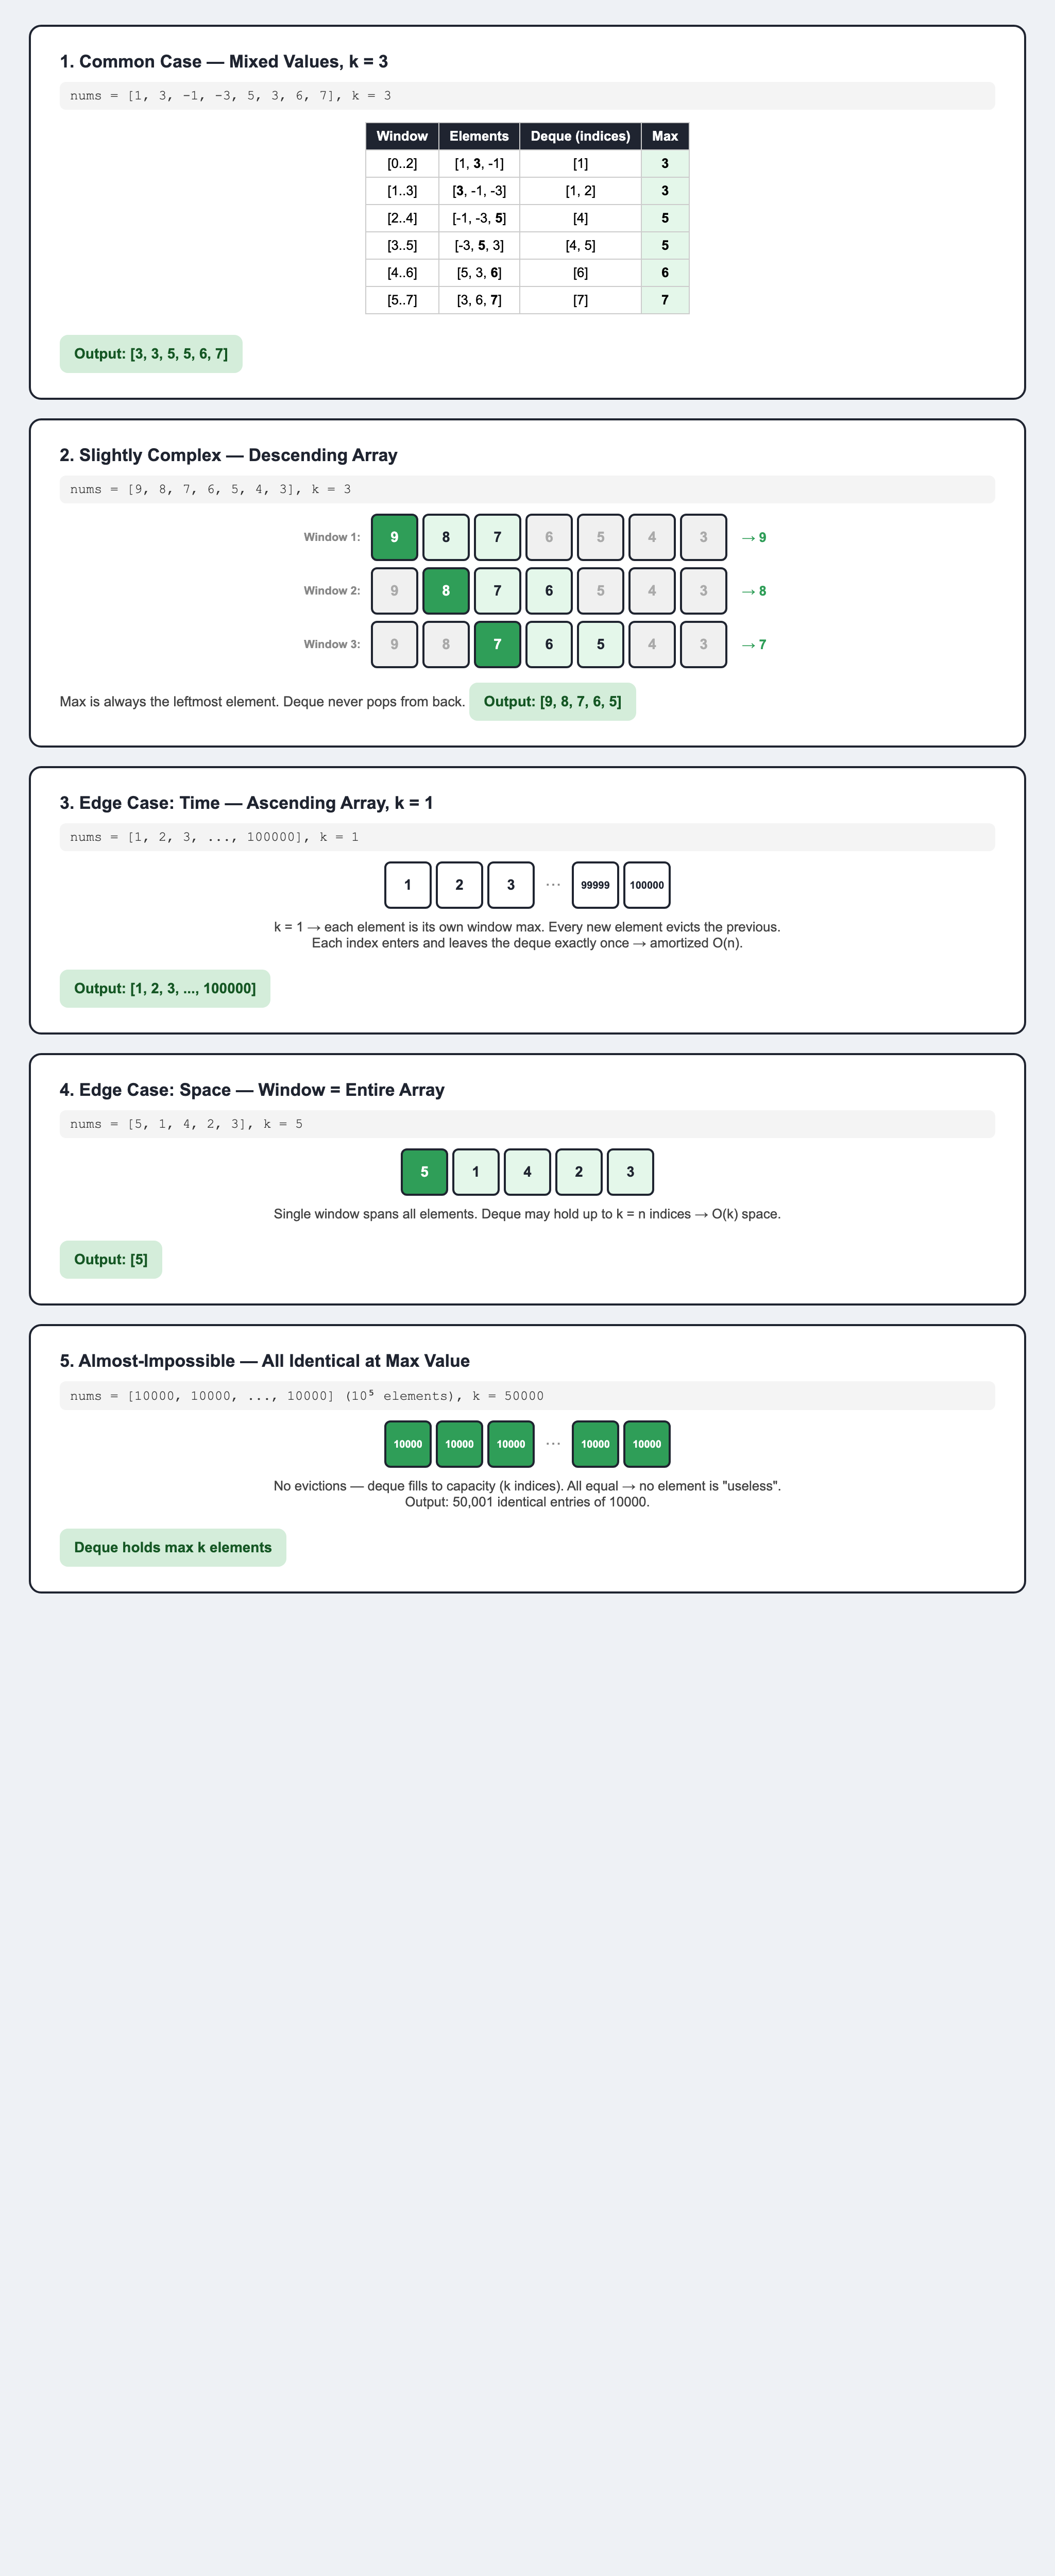